In [ ]:
# This chapter focuses on understanding the intricate dynamics of neural network 
#activations and gradients during training, specifically in the context of multi-layer 
#perceptrons (MLPs) and how these insights pave the way toward more complex architectures 
#like recurrent neural networks (RNNs), Gated Recurrent Units (GRUs), and Long Short-Term Memory 
#(LSTM) networks.
#• A solid grasp of how activations and gradients behave is crucial because they directly 
#impact the optimizability of neural networks using first-order gradient methods like stochastic
#gradient descent (SGD).


#• Key concepts include the role of logits, softmax output distributions, 
#activation functions such as tanh, and the problem of vanishing gradients 
#caused by saturated nonlinearities.

#• This chapter also introduces batch normalization, a modern technique that 
#standardizes activations to stabilize and improve training, especially in deeper networks.


#The starting point is a character-level MLP trained to predict the next 
#character given a small context window, using a vocabulary of 27 characters 
#(26 lowercase letters plus a special token).
#• The MLP has roughly 11,000 parameters and trains over 200,000 steps with batch size 32.
#• An important observation was the excessively high initial loss (~27), which is inconsistent with the expected loss for a uniform distribution over 27 characters (expected loss ≈ 3.29).
#• This indicated that the initial logits (pre-softmax activations) were improperly initialized, leading to overconfident but incorrect predictions and thus very high loss.
#Key points:
#• Expected initial output: uniform distribution over all characters → loss ≈
#negative log(1/27) ≈ 3.29.
#• Actual initial logits had extreme values causing overly confident wrong predictions 
#→ loss ≈ 27.


#

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [31]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) 
#* 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) 
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) 
#* 0

# BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [9]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 28.4938
  10000/ 200000: 2.8252
  20000/ 200000: 2.6110
  30000/ 200000: 2.7604
  40000/ 200000: 2.0706
  50000/ 200000: 2.7760
  60000/ 200000: 2.5257
  70000/ 200000: 1.9766
  80000/ 200000: 2.2394
  90000/ 200000: 2.3536
 100000/ 200000: 2.0312
 110000/ 200000: 2.4072
 120000/ 200000: 2.0116
 130000/ 200000: 2.5318
 140000/ 200000: 2.3986
 150000/ 200000: 2.1664
 160000/ 200000: 1.9884
 170000/ 200000: 1.8305
 180000/ 200000: 2.0130
 190000/ 200000: 2.0232


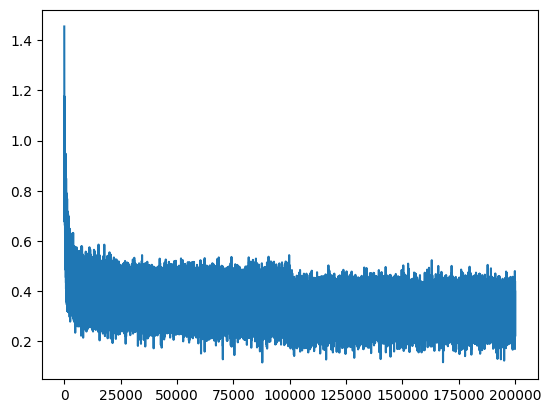

In [10]:

plt.plot(lossi)

In [15]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1

  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.464090585708618
val 2.4968535900115967


In [17]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      #forward pass the neural  net 
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
     # sample from the distribution 
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and teck the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token , break 
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word 

carlah.
aubriq.
khi.
mri.
reh.
cannandleena.
hehbaquelaha.
areli.
nerinia.
ciaiimilone.
gre.
amondis.
quinn.
sroilothianni.
watt.
madiarishi.
kaen.
dru.
buhdyzaiia.
gianney.


In [ ]:
# Diagnosing Initialization Issues: Logits and Hidden Activations
#   Logits are computed as a linear transformation of hidden activations: logits = H × W₂ + b₂.
# • Two main initialization problems:
# • Biases b₂ were randomly initialized, causing the logits to be offset arbitrarily. 
#     Setting these biases to zero helps ensure logits cluster around zero.
# • Weight matrix W₂ was too large in scale, leading to logits with large magnitudes, 
# pushing softmax outputs to extremes and causing unstable loss. Scaling weights down 
# (e.g., multiplying by 0.1) brought logits closer to zero and loss closer to the expected value.
# • Initializing weights exactly to zero is discouraged because it breaks symmetry breaking,
# which is necessary for neurons to learn distinct features. Instead, small random values are preferred to maintain some variability.
# • Hidden activations H are passed through the tanh (10h) nonlinearity, which squashes
# inputs to the range [-1, 1].
# • Visualization showed many activations saturated at -1 or 1, meaning neurons are 
# operating in the flat regions of tanh, which causes vanishing gradients during 
# backpropagation because the derivative of tanh approaches zero at these extremes.
# Key points:
# • Vanishing gradients occur when activations saturate nonlinearities (tanh, sigmoid).
# • Dead neurons: neurons that never activate in the linear region, thus never learn 
#     (gradient always zero).
# • Similar issues occur with ReLU neurons when they never activate (always negative input).
# Proper initialization must keep pre-activations within a range that avoids saturation.


#Initialization of neural networks is critical. A misconfigured initialization can produce
# extremely high initial loss values (e.g., 27 (for me 28)instead of an expected ~3.29 for uniform 
# probability across 27 possible characters). This happens because logits at initialization
# are often not centered or uniform, causing the softmax to be “confidently wrong” and 
# producing exaggerated loss values. Adjusting biases to zero and scaling weights 
#     (e.g., multiplying by 0.01 or 0.1)
# helps center logits closer to zero, producing more

In [19]:
-torch.tensor(1/28.0).log()

tensor(3.3322)

In [21]:
# 4 dimensional example of the issue 
logits = torch.tensor([0.0,0.0,0.0,0.0])
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs , loss


#• Initial loss at iteration 0 is unexpectedly high (~27), indicating poor initialization.
# • Expected initial loss calculation:
# • With 27 possible characters, a uniform distribution would assign ~1/27 probability
# to each, resulting in expected loss ≈ -log(1/27) ≈ 3.29.
# • Actual logits at initialization are confident but wrong, causing very high loss.
# • Example with 4 logits shows that logits close to zero produce a uniform softmax
# and expected loss ~1.38.
# • Extreme logits cause overconfident wrong predictions → exploding initial loss.
# • Identified root cause: Bias term (b2) initialized randomly, causing offset logits.
# • Solution:
# • Set output bias to zero at initialization.
# • Scale output weight matrix W2 by a small factor (e.g., 0.1) to keep logits near zero.
# • Result:
# • Initial loss drops to expected values (~3.29).
# • Training loss curve becomes smoother without initial “hockey-stick” shape, indicating 
# more efficient training without wasting iterations just squashing logits.
# Caution against setting weights exactly to zero to avoid symmetry breaking issues.

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [22]:
logits = torch.tensor([0.0,0.0,5.0,0.0])
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs , loss

(tensor([0.0066, 0.0066, 0.9802, 0.0066]), tensor(0.0200))

In [23]:
logits = torch.tensor([-3.0,0.0,5.0,2.0])
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs , loss # high loss

(tensor([3.1741e-04, 6.3754e-03, 9.4620e-01, 4.7108e-02]), tensor(0.0553))

In [25]:
#logits = torch.tensor([-3.0,0.0,5.0,2.0])
logits = torch.randn(4)
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits , probs , loss # high loss

(tensor([ 0.2431, -0.2310,  0.6342,  0.7794]),
 tensor([0.2079, 0.1294, 0.3073, 0.3554]),
 tensor(1.1798))

In [26]:
#logits = torch.tensor([-3.0,0.0,5.0,2.0])
logits = torch.randn(4) *10
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits , probs , loss # high loss

(tensor([-12.0852,  -3.8245,  -3.4141,  14.1502]),
 tensor([4.0375e-12, 1.5620e-08, 2.3545e-08, 1.0000e+00]),
 tensor(17.5644))

In [27]:
#logits = torch.tensor([-3.0,0.0,5.0,2.0])
logits = torch.randn(4) *100
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits , probs , loss # high loss

(tensor([-145.1669,  -66.0071,  -34.3367,  -12.5568]),
 tensor([0.0000e+00, 6.1213e-24, 3.4761e-10, 1.0000e+00]),
 tensor(21.7799))

In [28]:
logits = torch.tensor([1.0,1.0,1.0,1.0])
#logits = torch.randn(4) *100
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits , probs , loss # high loss

(tensor([1., 1., 1., 1.]),
 tensor([0.2500, 0.2500, 0.2500, 0.2500]),
 tensor(1.3863))

In [32]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  break

      0/ 200000: 28.4938


In [33]:
logits[0]

tensor([ -4.4602,  32.3673, -11.6979,   5.5694,  20.0895,  -6.2950,  -8.1618,
         -2.7348,  -0.2872,  11.4558,  17.1132,  -6.7761,   6.7740, -24.2789,
        -11.2737,   6.2158,  -2.4765,  -9.5571, -29.2264,  -6.8632,  24.5954,
          8.4046,  15.8890, -10.7344, -19.6579,   7.8470,  11.4100],
       grad_fn=<SelectBackward0>)

In [46]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) 
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

# BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [47]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.3277
  10000/ 200000: 2.2796
  20000/ 200000: 2.4154
  30000/ 200000: 2.6209
  40000/ 200000: 1.9621
  50000/ 200000: 2.3349
  60000/ 200000: 2.4446
  70000/ 200000: 2.1641
  80000/ 200000: 2.3063
  90000/ 200000: 2.2793
 100000/ 200000: 1.8783
 110000/ 200000: 2.1199
 120000/ 200000: 1.9415
 130000/ 200000: 2.2646
 140000/ 200000: 2.2047
 150000/ 200000: 2.1859
 160000/ 200000: 1.8602
 170000/ 200000: 1.7062
 180000/ 200000: 1.9129
 190000/ 200000: 1.9113


In [48]:
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
 #0/ 200000: 4.3060

#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#0/ 200000: 3.3277

#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
 #0/ 200000: 3.2958

In [50]:
logits[0]

tensor([-1.7567,  2.0931, -1.2374, -0.7336,  0.4597,  2.2656, -2.2688, -2.5218,
        -0.3753,  2.9033, -1.3733, -1.5763,  2.4493,  1.5945,  3.8119,  1.7838,
        -1.0283, -6.2341,  1.8296,  1.5041,  0.5679, -0.2424,  0.5388, -2.2688,
        -1.4238,  2.6549, -0.5895], grad_fn=<SelectBackward0>)

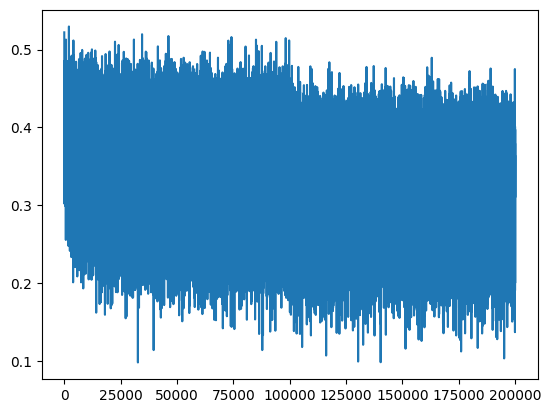

In [52]:
plt.plot(lossi)
#Training loss curve becomes smoother without initial “hockey-stick” shape, 
#indicating more efficient training without wasting iterations just squashing logits.

In [53]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1

  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.218261480331421
val 2.270460844039917


In [54]:
# train 2.464090585708618
# val 2.4968535900115967
#improved result from previous

In [55]:
h

tensor([[ 0.9999,  0.2669, -0.9835,  ..., -1.0000,  1.0000,  0.9999],
        [ 0.9997, -0.9997, -1.0000,  ..., -0.9877,  0.7913,  0.9792],
        [-1.0000,  1.0000, -1.0000,  ..., -0.9998, -1.0000, -0.7166],
        ...,
        [-0.9994, -0.9884, -1.0000,  ...,  0.7980, -0.9389, -0.9994],
        [ 1.0000,  0.7269,  1.0000,  ..., -0.8666, -1.0000,  1.0000],
        [ 0.6903, -0.6947, -1.0000,  ..., -0.9978, -1.0000,  0.6784]],
       grad_fn=<TanhBackward0>)

In [56]:
h.shape

torch.Size([32, 200])

In [57]:
h.view(-1).shape

torch.Size([6400])

In [60]:
#h.view(-1).tolist()

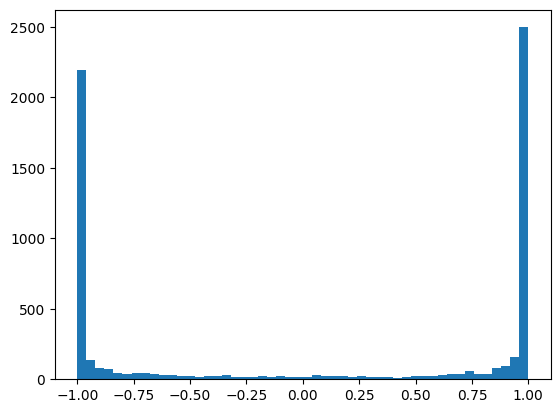

In [61]:
plt.hist(h.view(-1).tolist(),50);

In [64]:
#• Examination of hidden activations h after the tanh nonlinearity reveals many values saturate at -1 or 1.
# • Histogram shows pre-activations spanning large ranges (-5 to 15), causing tanh
# outputs to saturate.
# • Explanation:
# • Tanh saturates at ±1 at tails; gradients vanish because derivative of tanh is zero 
# at these points.
# • Backpropagation through saturated tanh kills gradients → vanishing gradients problem.
# • Concept of dead neurons: neurons that never activate in the “linear” region of tanh 
# (always saturated), thus never learn.
# • Dead neuron problem extends beyond tanh to sigmoid and ReLU:
# • ReLU dead neurons occur if pre-activation always negative → gradient zero forever.
# • Dead neurons cause permanent loss of capacity in the network.
# • Solution: Control scale of weights and biases to keep pre-activations near zero 
# at initialization.
# • Scale weights and biases down (e.g., multiply by 0.1 or 0.2).
# • Result: Hidden activations become less saturated, gradients flow better, training improves.
# • Improvement in validation loss from 2.17 → 2.10 by fixing saturation issue.
# • Warning: Such issues are more severe in deeper networks.


#Activations, specifically the outputs of the tanh nonlinearity, must be controlled. 
# If many tanh activations saturate near ±1, gradients vanish because the derivative of
# tanh near those saturation points approaches zero, effectively killing gradient flow
#     (the vanishing gradient problem). The lecture explains the mathematical reason why
# saturation leads to zero gradients, and how this results in “dead neurons” that never 
# activate or learn. This problem also applies to other nonlinearities like sigmoid and 
# ReLU (dead ReLU neurons). Proper initialization—scaling weights and biases to keep 
# pre-activations near zero—reduces saturation and improves gradient flow.

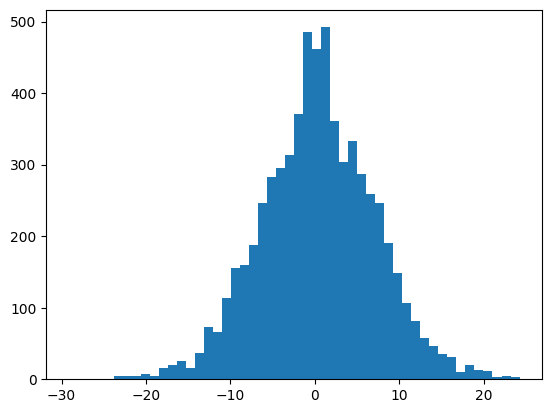

In [65]:
plt.hist(hpreact.view(-1).tolist(),50);

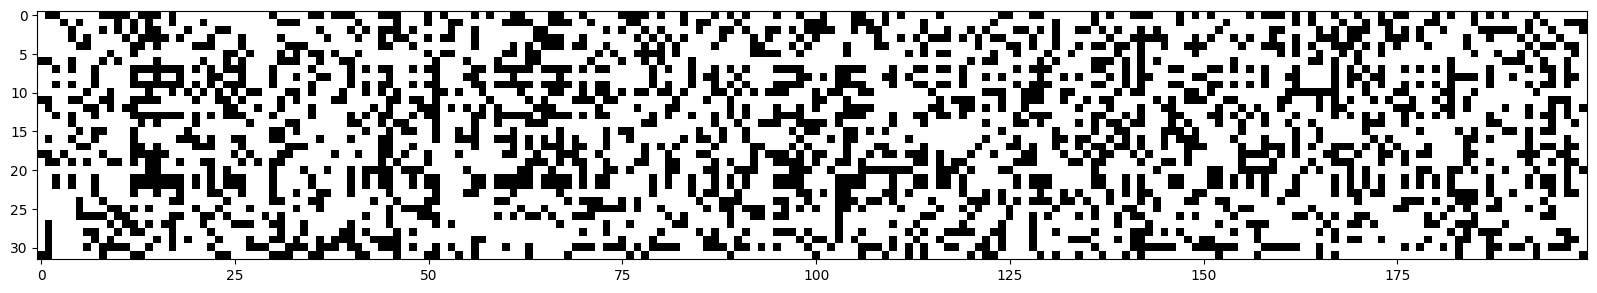

In [67]:
#fixing the saturated tanh 
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray' , interpolation='nearest')
#boolean tensor black false white true 
#all white=dead neuron

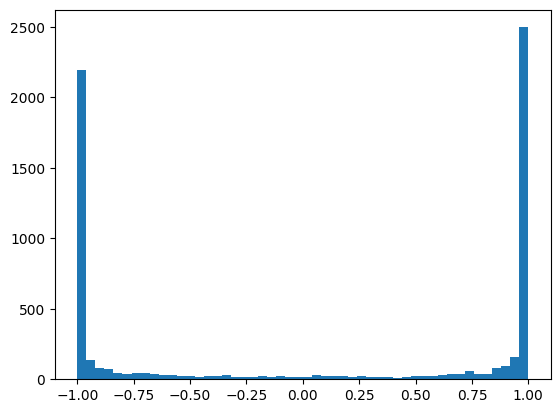

In [69]:
plt.hist(h.view(-1).tolist(), 50);

In [76]:
#from IPython.core.display import Image, display
from IPython.display import Image, display
display(Image(url='https://149695847.v2.pressablecdn.com/wp-content/uploads/2019/01/act-func.png', width=1900, unconfined=True))

In [99]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *0.2
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

# BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [100]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  break

      0/ 200000: 3.3134


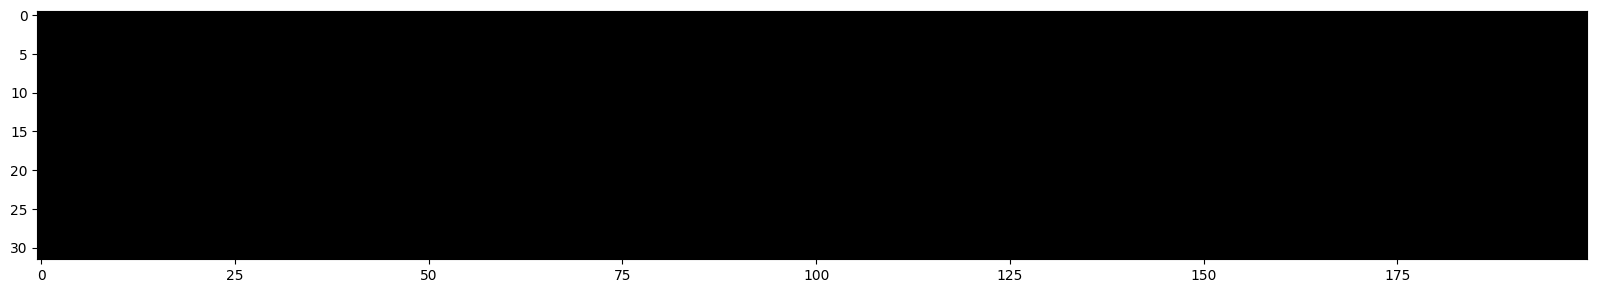

In [98]:
#fixing the saturated tanh 
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray' , interpolation='nearest')
#boolean tensor black false white true 
#all white=dead neuron
#W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *0.1

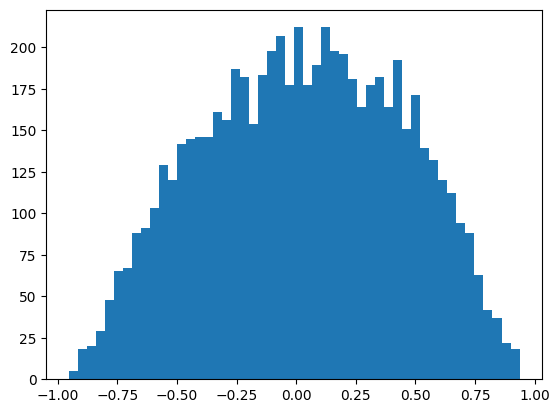

In [96]:
plt.hist(h.view(-1).tolist(),50);

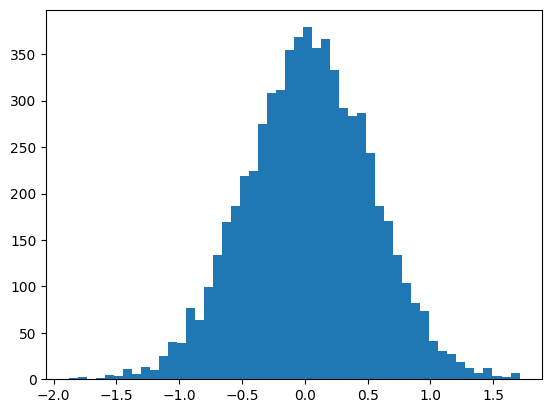

In [97]:
plt.hist(hpreact.view(-1).tolist(),50);

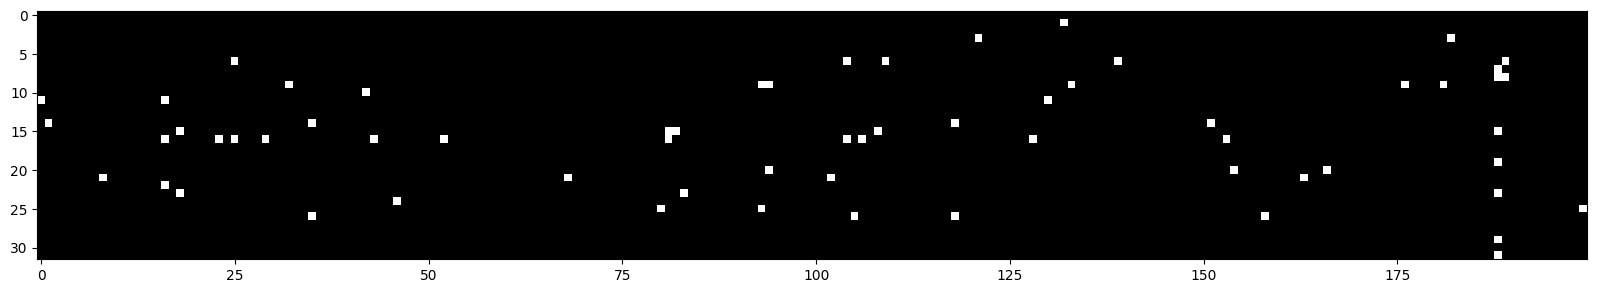

In [101]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray' , interpolation='nearest')
#W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *0.2

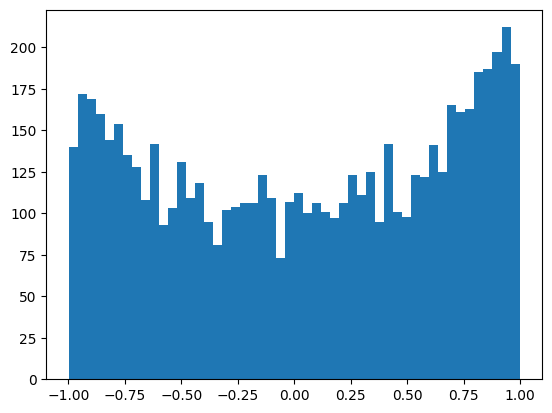

In [102]:
plt.hist(h.view(-1).tolist(),50);

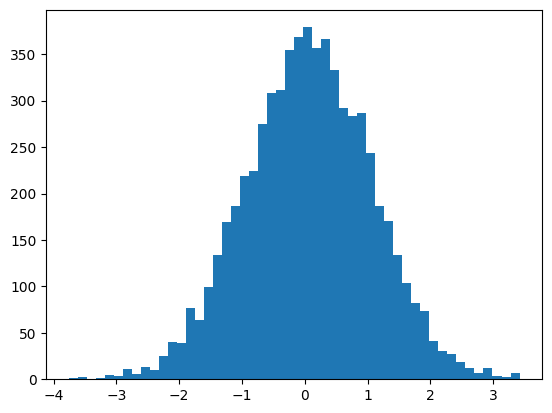

In [103]:
plt.hist(hpreact.view(-1).tolist(),50);

In [105]:
#without break 
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *0.2
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

# BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [107]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.2471
  10000/ 200000: 1.9211
  20000/ 200000: 1.9065
  30000/ 200000: 1.9864
  40000/ 200000: 2.0715
  50000/ 200000: 1.9750
  60000/ 200000: 2.0525
  70000/ 200000: 2.3668
  80000/ 200000: 2.5029
  90000/ 200000: 2.2021
 100000/ 200000: 2.2532
 110000/ 200000: 1.8517
 120000/ 200000: 2.2055
 130000/ 200000: 2.0011
 140000/ 200000: 1.7948
 150000/ 200000: 2.3951
 160000/ 200000: 2.1101
 170000/ 200000: 1.6990
 180000/ 200000: 1.9027
 190000/ 200000: 2.0604


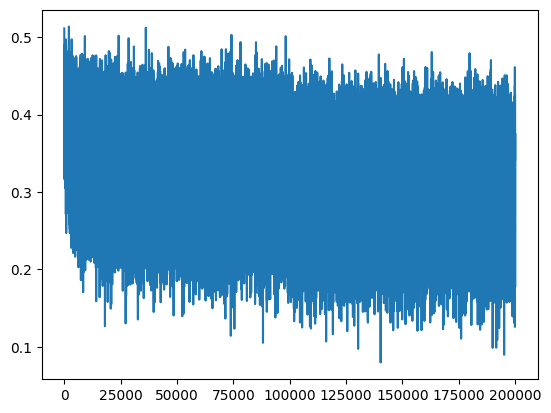

In [108]:
plt.plot(lossi)

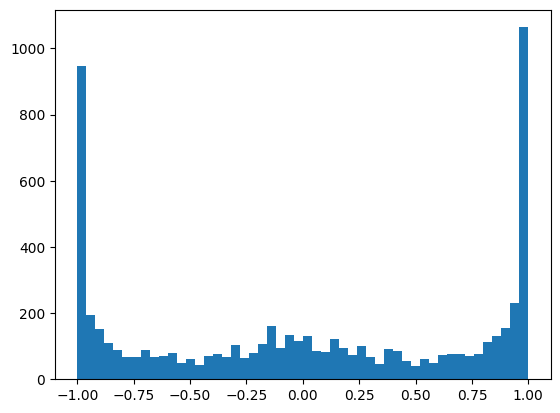

In [109]:
plt.hist(h.view(-1).tolist(),50);

In [110]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1

  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0360500812530518
val 2.102860927581787


In [ ]:
#loss log 
#original 
 train 2.464090585708618
 val 2.4968535900115967

#fix softmax 

train 2.218261480331421
val 2.270460844039917
# fix tanh too saturated at init
train 2.0360500812530518
val 2.102860927581787

In [ ]:
# Proper initialization aims to keep signal variances constant across layers, 
# avoiding exploding or vanishing activations.
# • Multiplying random inputs by weight matrices changes the variance of signals passed forward:
# • Without scaling, variance grows or shrinks uncontrollably.
# • The solution is to scale weights by 1 / √fan_in, where fan_in is the number of 
# inputs to a neuron.
# • This principle, stemming from variance-preserving initialization, ensures that 
# inputs to each layer maintain consistent variance.
# • The He et al. (2015) paper extended this by analyzing initialization for ReLU 
# activations, suggesting scaling weights by √(2/fan_in) to compensate for ReLU’s 
#     zeroing of negative inputs.
# • For tanh activations, a different gain (approx. 5/3) is advised to counteract 
# contraction effects of the tanh function.
# • These initialization schemes are implemented in deep learning frameworks like
# PyTorch as torch.nn.init.kaiming_normal_ or torch.nn.init.xavier_uniform_.
# Key points:
# • Initialization with fan-in scaling maintains stable variance in activations.
# • Gain factors adjust for different nonlinearities (ReLU, tanh, linear).
# • Proper initialization reduces training instability and improves convergence speed.


In [111]:
#without break 
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) *0.2
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

# BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


tensor(-0.0094) tensor(1.0008)
tensor(0.0009) tensor(3.1581)


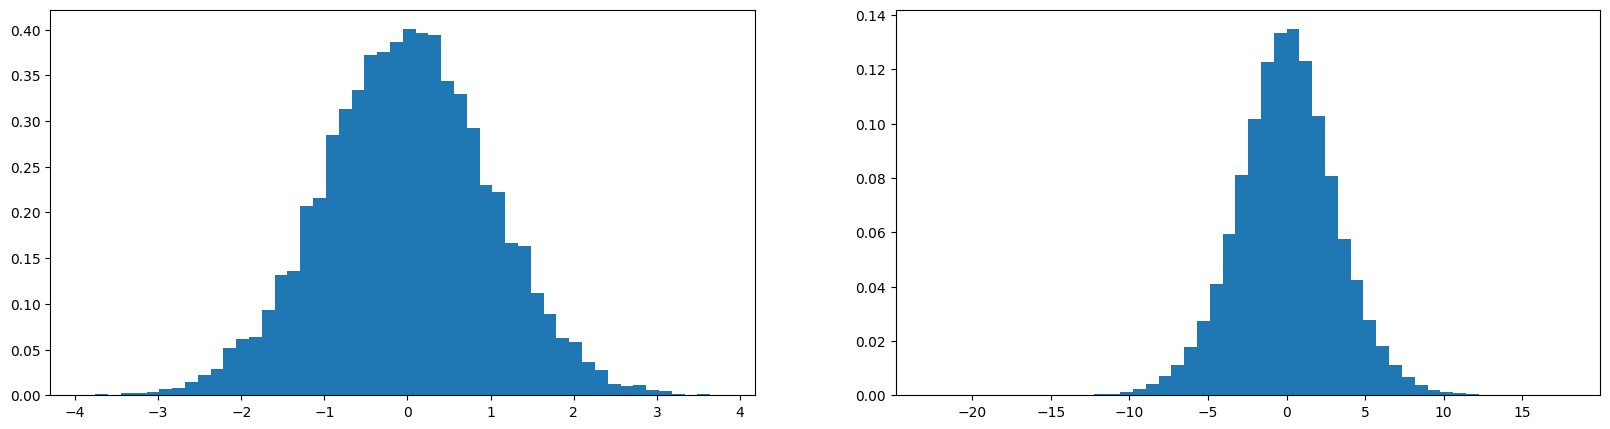

In [113]:
x = torch.randn(1000,10)
w = torch.randn(10,200)
y = x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);


tensor(-0.0062) tensor(0.9910)
tensor(0.0235) tensor(15.7260)


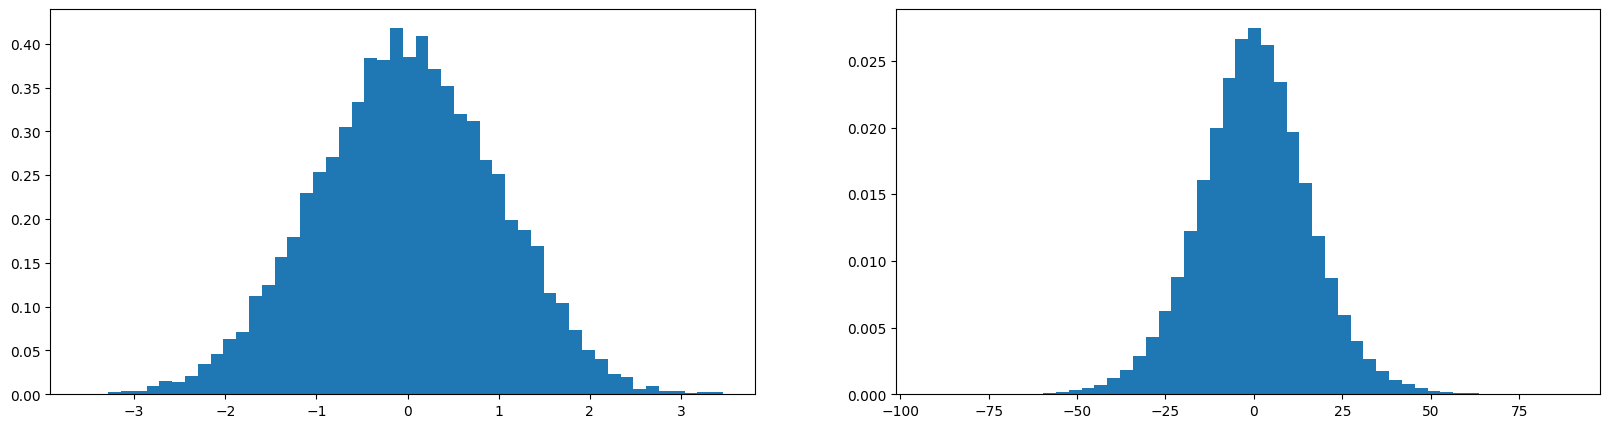

In [114]:
x = torch.randn(1000,10)
w = torch.randn(10,200) * 5
y = x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);


tensor(-0.0074) tensor(1.0045)
tensor(0.0027) tensor(0.6303)


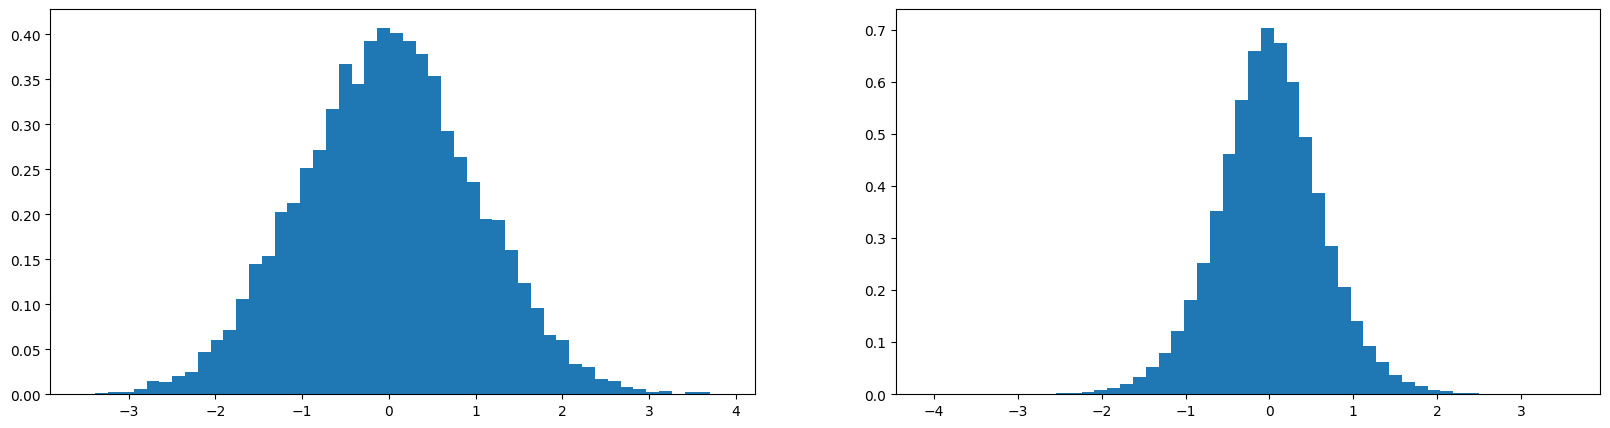

In [115]:
x = torch.randn(1000,10)
w = torch.randn(10,200) * 0.2
y = x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);


tensor(0.0006) tensor(1.0025)
tensor(-0.0044) tensor(0.9988)


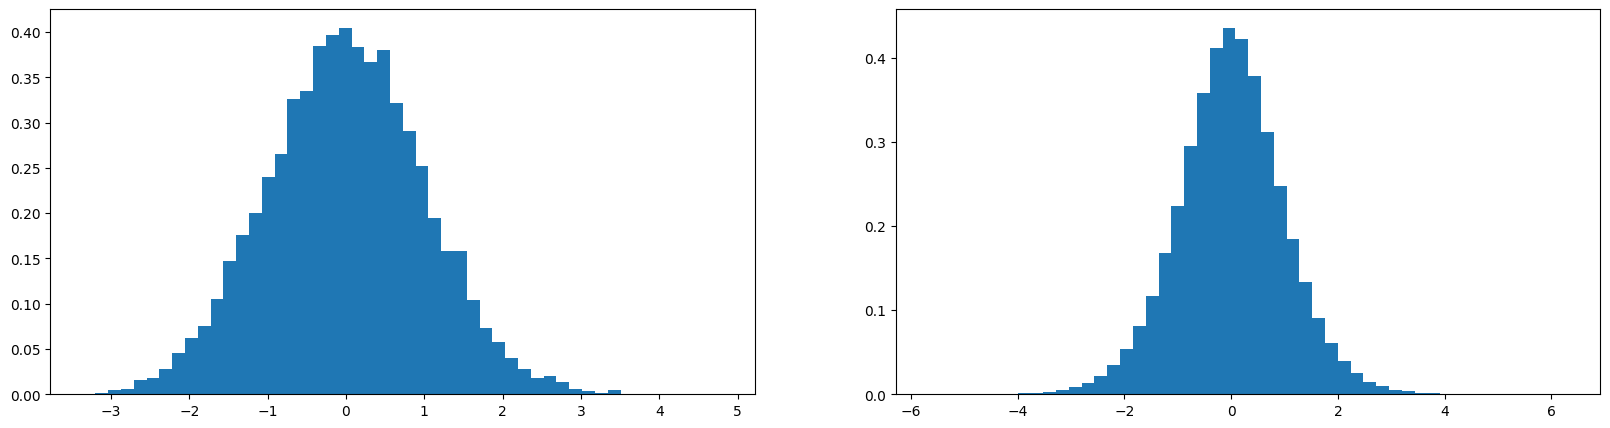

In [117]:
#solution
x = torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5
y = x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);


In [118]:
#https://arxiv.org/pdf/1502.01852

In [119]:
from IPython.display import IFrame

# Replace 'bengio03a.pdf' with the path to your PDF
IFrame('https://arxiv.org/pdf/1502.01852', width=800, height=600)

In [ ]:
#https://docs.pytorch.org/docs/stable/nn.init.html
#torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu', generator=None)[source]


In [ ]:
# As networks deepen, precise initialization becomes less tractable due to complex 
# interactions among layers.
# • Batch Normalization (BatchNorm) standardizes layer inputs to have zero mean 
# and unit variance within each training batch.
# • Implementation steps:
# 1. Compute batch mean and variance of pre-activations.
# 2. Normalize activations: subtract mean and divide by standard deviation.
# 3. Apply learned scale (gamma) and shift (beta) parameters to allow the network 
#     to adjust normalized values.
# • BatchNorm is differentiable and integrated into the network’s computation graph,
#     allowing gradients to flow through normalization steps.
# • During training, running averages of mean and variance are maintained and used 
#         during inference to avoid dependence on batch data.
# • BatchNorm stabilizes training by preventing activations from saturating nonlinearities, 
#     effectively controlling internal covariate shift.
# • However, BatchNorm introduces coupling between examples in a batch because normalization
#     depends on batch statistics, causing subtle noise and jitter in activations, which
#     surprisingly acts as a regularizer and reduces overfitting.
# • Despite its benefits, BatchNorm can cause bugs and complexity due to this coupling,
# motivating alternative normalization methods like layer normalization, instance normalization,
# and group normalization, which do not depend on batch statistics.
# Key points:
# • BatchNorm stabilizes training by normalizing activations within batches.
# • Introduces learnable gain and bias parameters (gamma and beta).
# • Uses running statistics to enable inference on single examples.
# • Acts as implicit regularization via batch-dependent noise.
# • Coupling of batch examples complicates use and debugging.


# Batch Normalization: Concept, Implementation, and Impact
# • Batch Normalization (BatchNorm) introduced in 2015 (Ioffe & Szegedy) to 
# stabilize training of deep networks.
# • Core idea: Normalize hidden layer pre-activations to have zero mean and unit 
# variance within each batch.
# • Benefits:
# • Controls scale of activations dynamically during training.
# • Reduces saturation problems by maintaining Gaussian-like distributions.
# • Enables use of higher learning rates and faster convergence.
# • Implementation details:
# • Calculate batch mean and variance per neuron.
# • Normalize activations: subtract mean, divide by std deviation.
# • Introduce learned scale (gamma) and shift (beta) parameters to allow 
#     network to adapt normalized activations.
# • Maintain running averages of mean and variance during training for use at inference.
# • Challenges:
# • BatchNorm couples examples in the batch, meaning activations depend on
#     other examples, causing subtle “jitter”.
# • This coupling acts as a form of regularization (similar to data augmentation).
# • At test time, need to use running averages instead of batch statistics for consistency.
# • In PyTorch:
# • Use torch.nn.BatchNorm1d (or 2d for images) layers.
# • Disable bias in preceding linear/convolutional layers, as BatchNorm includes bias.
# • Momentum controls running average updates; smaller momentum recommended for
#         small batch sizes.
# • Discussion on epsilon (small constant added to variance for numerical stability).
# • BatchNorm widely used in modern architectures but has downsides:
# • Complexity in implementation.
# • Hard to use with very small batch sizes.
# • Alternatives like LayerNorm, GroupNorm, InstanceNorm exist.





In [124]:
#without break 
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3)/((n_embd * block_size)**0.5)
#*0.2
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

# BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [125]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.3179
  10000/ 200000: 2.1931
  20000/ 200000: 2.3239
  30000/ 200000: 2.5364
  40000/ 200000: 1.9723
  50000/ 200000: 2.3183
  60000/ 200000: 2.3864
  70000/ 200000: 2.1508
  80000/ 200000: 2.3094
  90000/ 200000: 2.2279
 100000/ 200000: 1.8242
 110000/ 200000: 2.1281
 120000/ 200000: 1.9468
 130000/ 200000: 2.3681
 140000/ 200000: 2.1050
 150000/ 200000: 2.1441
 160000/ 200000: 1.7716
 170000/ 200000: 1.7771
 180000/ 200000: 1.9463
 190000/ 200000: 1.8029


In [127]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1

  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0388665199279785
val 2.108630418777466


In [129]:
# fix tanh too saturated at init
#train 2.0360500812530518
#val 2.102860927581787
#same

In [121]:
(torch.randn(10000)*0.2).std()

tensor(0.1987)

In [122]:
n_embd * block_size


30

In [123]:
(5/3) / (30**0.5)

0.3042903097250923

In [130]:
from IPython.display import IFrame

# Replace 'bengio03a.pdf' with the path to your PDF
IFrame('https://arxiv.org/pdf/1502.03167', width=800, height=600)

In [ ]:
# • Batch Normalization Mechanics
# • Normalizes pre-activations per batch to zero mean, unit variance.
# • Adds learnable scale (gamma) and shift (beta) parameters.
# • Maintains running averages of mean and variance for use during inference.
# • Regularizes training by adding noise via batch coupling.
# Causes issues with coupling examples, leading to bugs and complexity.

In [131]:
hpreact.shape

torch.Size([32, 200])

In [133]:
hpreact.mean(0,keepdim=True).shape

torch.Size([1, 200])

In [134]:
hpreact.std(0,keepdim=True).shape

torch.Size([1, 200])

In [137]:
#without break 
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3)/((n_embd * block_size)**0.5)
#*0.2
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

#scale and shift
# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
#bnmean_running = torch.zeros((1, n_hidden))
#bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2 , bngain, bnbias ]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [138]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  #mini batch variance and mini batch mean 
  #hpreact = (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True)
  #scale and shift
  hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) + bnbias
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


In [139]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  #scale and shift 
  hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.0668270587921143
val 2.104844808578491


In [140]:
#loss log 
# #original 
#  train 2.464090585708618
#  val 2.4968535900115967

# #fix softmax 

# train 2.218261480331421
# val 2.270460844039917
# # fix tanh too saturated at init
# train 2.0360500812530518
# val 2.102860927581787

# # use semi-prinicipled "kaiming init" instead of hacky init:
# train 2.0388665199279785
# val 2.108630418777466

# #add a batch norm layer 
# train 2.0668270587921143
# val 2.104844808578491


In [145]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [146]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  #scale and shift 
  #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.066890239715576
val 2.1049015522003174


In [ ]:
#loss log 
# #original 
#  train 2.464090585708618
#  val 2.4968535900115967

# #fix softmax 

# train 2.218261480331421
# val 2.270460844039917
# # fix tanh too saturated at init
# train 2.0360500812530518
# val 2.102860927581787

# # use semi-prinicipled "kaiming init" instead of hacky init:
# train 2.0388665199279785
# val 2.108630418777466

# #add a batch norm layer 
# train 2.0668270587921143
# val 2.104844808578491

#after calribrate
# train 2.066890239715576
# val 2.1049015522003174


In [156]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3)/((n_embd * block_size)**0.5)
#*0.2
#* (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
#* 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
#W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
#* 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0
#* 0

#scale and shift
# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,b1, W2, b2 , bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [157]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  #mini batch variance and mini batch mean 
  #hpreact = (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True)
  #scale and shift
  #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) + bnbias
  bmeani = hpreact.mean(0,keepdim=True)
  bnstdi = hpreact.std(0,keepdim=True)
  hpreact = bngain * (hpreact - bmeani)/bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # ------------------------------------------------------------
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
       if p.grad is not None:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  #break

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


In [158]:
bnmean

tensor([[-2.3148,  0.6874, -0.9136,  0.9966,  1.0880,  1.0840,  1.7472, -2.1107,
          0.5818,  1.4375, -1.6466, -2.7301, -0.4766, -0.1641, -0.0858, -1.1704,
          0.6867, -2.6103, -0.0924,  1.6207, -0.7664, -0.3184,  0.0414,  0.6149,
          1.1046,  0.2279,  2.0388,  0.5843,  0.8446,  1.7754, -0.3646, -0.8379,
         -0.0896, -0.5023, -0.3711, -1.0608, -0.0749,  0.3473, -0.5914,  0.9716,
         -0.4422, -1.3040, -0.3001, -0.2147,  0.6885,  0.6893,  2.0853, -0.7506,
          2.3778,  1.8862,  0.8296,  0.2895,  1.8993,  0.4668,  0.6838, -1.8916,
         -0.0522,  0.4209,  1.3688, -0.9078, -0.4528,  1.1846,  0.5668,  0.6121,
          1.5833,  1.2313, -1.0180,  2.1523, -0.6460,  0.0949, -0.2969, -0.4722,
          0.9620, -1.0408, -2.9998,  0.6501,  1.4310, -0.1545,  0.0938,  0.5273,
          0.2381,  1.2512,  2.0559,  0.6612,  0.0664, -0.0787, -1.6763,  0.2953,
          2.2552, -0.0272, -0.6879,  1.4155, -0.8440, -1.2223, -1.0225,  0.2299,
          0.2184, -0.3140,  

In [159]:
bnmean_running

tensor([[-2.3539,  0.6872, -0.9000,  1.0159,  1.0894,  1.0862,  1.7389, -2.1356,
          0.5608,  1.4246, -1.6445, -2.7426, -0.4861, -0.1510, -0.0687, -1.1550,
          0.6891, -2.6399, -0.1283,  1.6241, -0.7732, -0.2865,  0.0467,  0.6119,
          1.1172,  0.2433,  2.0542,  0.5778,  0.8515,  1.7729, -0.3741, -0.8385,
         -0.0831, -0.5198, -0.3816, -1.0698, -0.0781,  0.3370, -0.5769,  0.9935,
         -0.4507, -1.3313, -0.2895, -0.2299,  0.6877,  0.6936,  2.0835, -0.7759,
          2.3804,  1.8613,  0.8118,  0.2735,  1.8802,  0.4704,  0.6656, -1.8962,
         -0.0420,  0.4356,  1.3924, -0.8906, -0.4676,  1.1688,  0.5539,  0.6000,
          1.5853,  1.2103, -1.0171,  2.1422, -0.6330,  0.1071, -0.2926, -0.4831,
          0.9506, -1.0144, -2.9925,  0.6268,  1.4404, -0.1574,  0.0955,  0.5159,
          0.2487,  1.2400,  2.0104,  0.6695,  0.0768, -0.0851, -1.6767,  0.2963,
          2.2374, -0.0100, -0.6669,  1.4356, -0.8431, -1.2317, -1.0220,  0.2201,
          0.1928, -0.3261,  

In [160]:
bnstd

tensor([[2.3929, 2.1364, 2.2663, 1.9944, 2.1860, 2.3736, 2.2576, 2.3451, 2.3578,
         2.1045, 2.4973, 2.2571, 2.1519, 2.2017, 2.0989, 2.7105, 2.4423, 1.8902,
         2.2073, 2.5144, 2.3232, 2.3402, 2.1268, 2.0214, 2.0374, 1.8407, 2.1634,
         2.6021, 2.2403, 2.3329, 1.7083, 1.9046, 2.0957, 1.8207, 2.0848, 1.9323,
         2.4885, 2.1671, 2.1170, 1.8611, 2.0108, 2.0911, 2.4064, 1.9754, 1.9694,
         2.4172, 2.1964, 2.5617, 2.1547, 2.4972, 2.0511, 1.8491, 2.0182, 1.7755,
         2.3971, 2.2095, 1.7725, 2.2930, 2.5639, 1.7747, 2.1165, 1.9382, 2.0266,
         2.2968, 2.1514, 2.3390, 2.1540, 2.4904, 2.0355, 2.1785, 2.0923, 1.9757,
         1.9921, 2.2561, 1.9101, 1.8626, 2.5723, 2.2043, 1.6819, 2.2513, 2.0126,
         1.8353, 2.0170, 2.2116, 2.5047, 2.3529, 2.1391, 2.3848, 2.5823, 2.6848,
         2.0914, 1.9556, 2.1099, 1.9680, 1.8658, 2.2201, 2.1905, 2.0695, 1.8927,
         2.3433, 2.0515, 2.1435, 2.2730, 2.0000, 1.9994, 2.2907, 1.8655, 2.2061,
         1.9252, 2.1527, 2.3

In [161]:
bnstd_running

tensor([[2.3689, 2.0998, 2.2499, 1.9599, 2.1515, 2.3429, 2.2431, 2.3104, 2.3309,
         2.0823, 2.4680, 2.2253, 2.1192, 2.1805, 2.0655, 2.6865, 2.4191, 1.8718,
         2.1882, 2.4989, 2.2903, 2.3143, 2.1068, 1.9938, 2.0172, 1.8189, 2.1352,
         2.5721, 2.2250, 2.3027, 1.6857, 1.8987, 2.0912, 1.8024, 2.0771, 1.9073,
         2.4759, 2.1356, 2.0873, 1.8440, 1.9877, 2.0603, 2.3704, 1.9412, 1.9464,
         2.4033, 2.1706, 2.5047, 2.1318, 2.4826, 2.0177, 1.8195, 1.9937, 1.7548,
         2.3758, 2.1857, 1.7500, 2.2775, 2.5494, 1.7520, 2.0970, 1.9272, 2.0154,
         2.2870, 2.1270, 2.3166, 2.1311, 2.4586, 2.0074, 2.1552, 2.0607, 1.9617,
         1.9790, 2.2358, 1.8885, 1.8480, 2.5581, 2.1731, 1.6619, 2.2316, 1.9924,
         1.8106, 1.9824, 2.1809, 2.4859, 2.3152, 2.1121, 2.3617, 2.5755, 2.6760,
         2.0648, 1.9299, 2.1034, 1.9445, 1.8592, 2.1894, 2.1640, 2.0496, 1.8632,
         2.3143, 2.0495, 2.1165, 2.2337, 1.9762, 1.9748, 2.2615, 1.8477, 2.1645,
         1.9084, 2.1207, 2.3

In [162]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  #scale and shift 
  #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) + bnbias
  #hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.06659197807312
val 2.1050572395324707


In [ ]:
#loss log 
# #original 
#  train 2.464090585708618
#  val 2.4968535900115967

# #fix softmax 

# train 2.218261480331421
# val 2.270460844039917
# # fix tanh too saturated at init
# train 2.0360500812530518
# val 2.102860927581787

# # use semi-prinicipled "kaiming init" instead of hacky init:
# train 2.0388665199279785
# val 2.108630418777466

# #add a batch norm layer 
# train 2.0668270587921143
# val 2.104844808578491

#after calribrate
# train 2.066890239715576
# val 2.1049015522003174

#bnstd_running bnmean_running
# train 2.06659197807312
# val 2.1050572395324707

In [ ]:
#if b1 is used above enabled it , this code is where andrej explain the b1 is not required 
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  #+ b1 not required now 
  #scale and shift 
  #hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True) + bnbias
  #hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


In [163]:
# The ResNet architecture, widely used in image classification, heavily relies 
# on batch normalization.
# • Residual blocks in ResNets consist of sequences of convolution → batch normalization 
# → ReLU layers, repeated multiple times.
# • BatchNorm layers here serve the same key purpose: controlling activation scales and 
# stabilizing gradients across very deep networks.
# • Bias terms in convolutional and linear layers preceding batch normalization are typically 
#     disabled, as biases are canceled out by normalization.
# • This motif of weight layer → batch normalization → nonlinearity is standard in modern 
# deep network design.

#from IPython.core.display import Image, display
from IPython.display import Image, display
display(Image(url='https://neurohive.io/wp-content/uploads/2019/01/resnet-architecture-3.png', width=1900, unconfined=True))

In [164]:
#https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py

In [165]:
#https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html

In [ ]:
#https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html

In [ ]:
# Practical PyTorch Implementation and Residual Networks
# • Code modularization: wrapping components into Linear, BatchNorm1d, and 
# #Tanh modules modeled after PyTorch’s API.
# • Layer stacking to build neural networks resembling PyTorch’s style.
# • Diagnostic tools introduced:
# • Histograms of activations and gradients at each layer.
# • Percent saturation of tanh activations (values near ±1).
# • Gradients statistics to detect vanishing/exploding gradients.
# • Parameter histogram and gradient-to-parameter ratio.
# • Update-to-parameter ratio over training iterations (log scale).
# • Empirical findings:
# • Without BatchNorm, careful gain tuning needed; activations and gradients can shrink or explode.
# • With BatchNorm, activations and gradients stabilize across layers and training steps.
# • BatchNorm improves robustness to initialization scaling.
# • Example: Residual Network (ResNet) blocks:
# • Sequence of convolution → batch norm → ReLU layers.
# • Residual connections (skip connections) improve gradient flow.
# • Bias disabled in convolution layers before BatchNorm, as BatchNorm handles bias.
# • Linear layer initialization details in PyTorch:
# • Uniform distribution scaled by 1 / sqrt(fan-in).
# • BatchNorm parameters: learnable gamma and beta, buffers for running mean/variance.
# • BatchNorm behavior differs between training and evaluation modes:
# • Training: use batch stats and update running stats.
# • Evaluation: use running stats only.
# torch.no_grad() context used to update running stats without building computation graph.



#  The lecture presents a modular implementation of a neural network with 
#components mimicking PyTorch’s API:
# • Linear layers, BatchNorm1d layers, and Tanh nonlinearities wrapped as modules.
# • Diagnostic tools include plotting histograms of activations, gradients,
#and weights across layers during training to identify issues such as saturation or dead neurons.
# • Key metrics monitored:
# • Activation saturation percentage (proportion of activations near ±1 in tanh).
# • Gradient distributions to detect vanishing or exploding gradients.
# • Weight statistics and update-to-parameter ratios, giving insight into training
#dynamics and whether learning rates are suitable.
# • Observations show that without batch normalization or careful initialization, 
#activations and gradients tend to shrink or explode, making training unstable.
# • BatchNorm substantially improves stability and robustness to hyperparameter changes
#like gain scaling and learning rates.
# • The update-to-data ratio metric helps in tuning learning rates by comparing gradient
#update magnitude relative to parameter magnitude.


In [ ]:
1:25:00

In [ ]:
#  Activation and Gradient Statistics, Gains, and Robustness
# • Investigated effect of gain on forward activations and backward gradients:
# • Gain too low → activations and gradients shrink, making training slow or impossible.
# • Gain too high → activations saturate, gradients explode, training unstable.
# • Tanh layers require gain ~5/3 to balance contraction of activations.
# • Without nonlinearities, multiple linear layers collapse to a single linear transformation, 
# losing expressive power.
# • Importance of nonlinearities like tanh or ReLU to model complex functions.
# • Gradient-to-parameter ratio and update-to-parameter ratio help diagnose training dynamics.
# • Update-to-parameter ratio around 10^-3 (log scale ~ -3) is a good heuristic for efficient
#     training.
# • Too small update ratios indicate learning rate too low; too large indicate too high.
# • BatchNorm layers allow relaxation of precise gain tuning but learning rate may still 
# need adjustment.
# • BatchNorm enables training deeper networks more reliably by controlling activation 
# distributions.
# • Experiments show BatchNorm reduces brittleness to initialization scale.
# • Without BatchNorm, misscaled weights cause poor activation and gradient statistics 
# and uneven training across layers.
# • BatchNorm allows use of random initialization without fan-in scaling but requires 
#     learning rate tuning.
